
[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
✅ Ratings already downloaded. Skipping.
✅ Metadata already downloaded. Skipping.
📂 Loading Amazon Electronics ratings...
   Raw: 7,824,482 ratings | 4,201,696 users | 476,002 products
✅ Filtered: 398,753 ratings | 20,000 users | 20,966 products
📂 Loading product metadata (this takes ~60s)...
✅ Products loaded: 0 with metadata
✅ All data validation checks passed
🔧 Building User-Item matrix...
✅ Matrix: 20,000 users × 20,966 products
   Sparsity: 99.9% of cells are unrated
✅ Split → Train: 319,002 | Test: 79,751


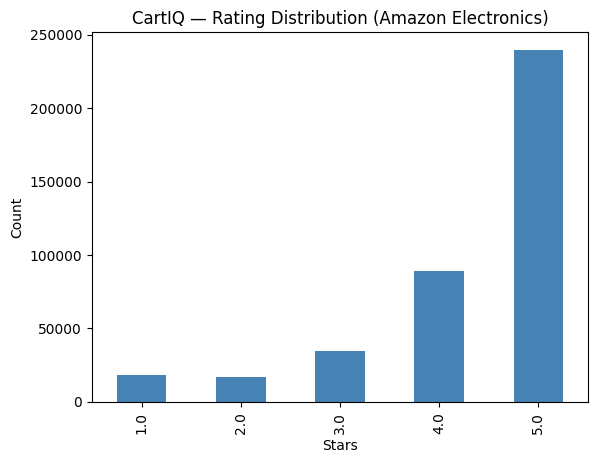

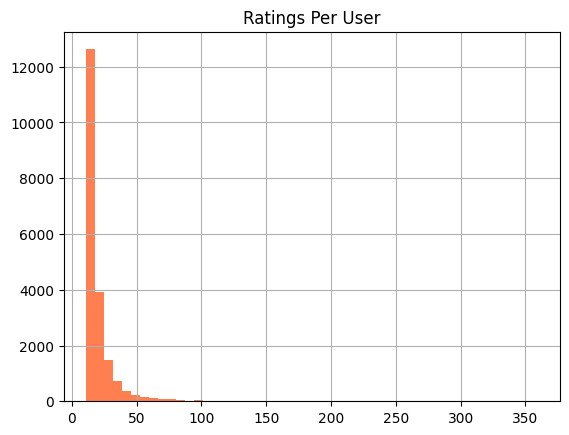

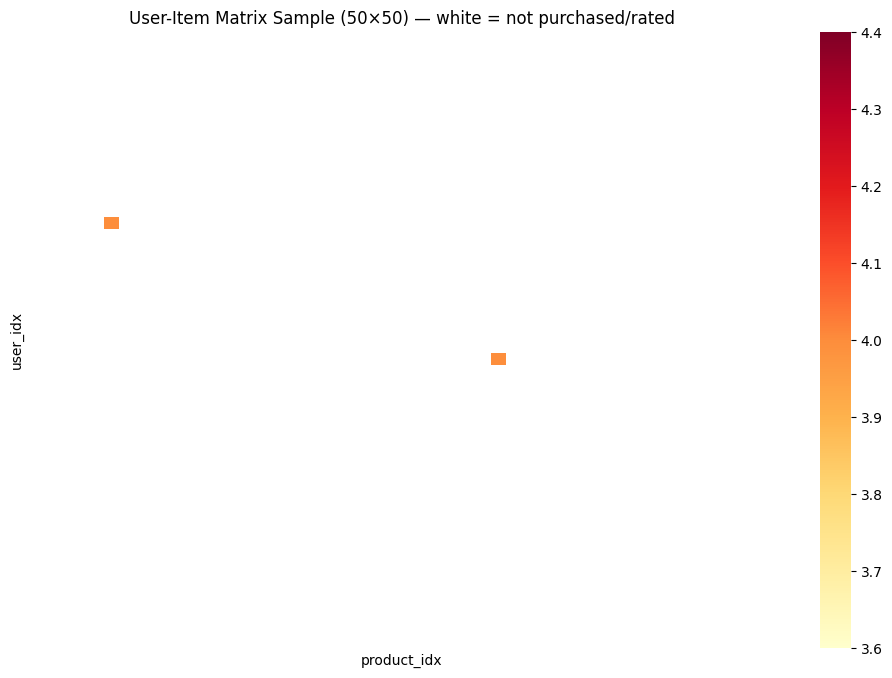

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn requests scikit-learn

# Cell 1 — Load
import sys; sys.path.append("../src")
from data_loader import load_all
ratings, products, matrix, train, test = load_all()

# Cell 2 — Rating distribution
import matplotlib.pyplot as plt
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("CartIQ — Rating Distribution (Amazon Electronics)")
plt.xlabel("Stars"); plt.ylabel("Count"); plt.show()
# Key insight: Amazon has a severe positivity bias — most ratings are 4–5 stars
# This is different from MovieLens (more 3s). Your model needs bias terms to handle this.

# Cell 3 — Ratings per user (long tail)
ratings.groupby("user_id")["rating"].count().hist(bins=50, color="coral")
plt.title("Ratings Per User"); plt.show()
# Key insight: Even after filtering ≥10 ratings, the tail is steep.
# Most users cluster at 10–15 ratings, a handful have 100+.

# Cell 4 — Top categories
if "category" in products.columns:
    top_cats = (
        ratings.merge(products[["product_id", "category"]], on="product_id")
        ["category"].value_counts().head(10)
    )
    top_cats.plot(kind="barh", color="teal")
    plt.title("Top 10 Product Categories by Rating Volume"); plt.show()

# Cell 5 — Sparsity heatmap (sample 50×50)
import seaborn as sns
sample = matrix.iloc[:50, :50].replace(0, float("nan"))
plt.figure(figsize=(12, 8))
sns.heatmap(sample, cmap="YlOrRd", xticklabels=False, yticklabels=False)
plt.title("User-Item Matrix Sample (50×50) — white = not purchased/rated")
plt.show()
# CartIQ sparsity will be ~99%+ vs MovieLens 93.7% — much harder problem,
# which is why SVD's latent factor approach matters even more here.